# Modelo Supervisado — Predicción de Completado vs Cancelado de Envíos

**Objetivo:** predecir si un pedido llegará a destino (`COMPLETE`) o será `CANCELED`, usando el dataset limpio enriquecido con los resultados del modelo no supervisado (`cluster_kmeans`, `cluster_dbscan`, `es_anomalia`, `es_outlier`).

Es un problema de **clasificación binaria**. Se entrenan y comparan varios algoritmos (Regresión Logística, Árbol de Decisión, Random Forest, XGBoost, SVM y KNN), se optimizan los dos mejores con búsqueda de hiperparámetros, se interpreta el modelo final (SHAP, importancia por permutación), se prueba un ensamble por stacking, se calibra la probabilidad, se evalúa la robustez y se documentan insights de negocio y el flujo de despliegue.

**V2 — cambios frente a la versión anterior:**
1. Se detectó que, además de `estado_entrega`, la variable `tipo_transaccion` también es fuga de datos (ver Sección 2) y se excluye del modelo.
2. Se añade un bloque de EDA (univariante, bivariante y de desbalanceo) antes de construir features.
3. Se añaden variables derivadas (ingeniería de características).
4. Se añade interpretabilidad avanzada (SHAP + importancia por permutación), un ensamble de *stacking*, calibración de probabilidades, análisis de robustez, insights de negocio y artefactos de despliegue.

> **Nota honesta:** al quitar `tipo_transaccion` (además de `estado_entrega`), es esperable que las métricas caigan de forma importante frente a la versión anterior (que llegaba a F1 ≈ 0.87). Eso no es un error: significa que gran parte de la señal que el modelo anterior estaba usando era, en realidad, fuga de datos. La Sección 13 (resumen final) documenta el resultado real una vez corregido.

## 1. Carga de datos

In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, cross_val_score, RandomizedSearchCV, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, roc_curve, confusion_matrix, classification_report
)
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

RANDOM_STATE = 42

df = pd.read_csv('DataCoSupplyChain_Limpio.csv')
print(f"Dimensiones: {df.shape}")
print(f"\nDistribución del target (estado_pedido):")
print(df['estado_pedido'].value_counts())
print(df['estado_pedido'].value_counts(normalize=True).round(3))

Dimensiones: (151087, 28)

Distribución del target (estado_pedido):
estado_pedido
COMPLETE    100041
CANCELED     51046
Name: count, dtype: int64
estado_pedido
COMPLETE    0.662
CANCELED    0.338
Name: proportion, dtype: float64


## 2. Revisión de fuga de datos (data leakage)

Antes de elegir las features, conviene verificar que ninguna variable sea **consecuencia** del resultado que se quiere predecir. Si una variable solo se conoce *después* de que el pedido se completó o canceló, incluirla como feature produce una precisión artificialmente alta e inútil en producción.

In [2]:
# estado_entrega estaba en la lista original de features propuesta.
# Se revisa su relación con el target antes de usarla.
print(pd.crosstab(df['estado_entrega'], df['estado_pedido']))

estado_pedido      CANCELED  COMPLETE
estado_entrega                       
Advance shipping      10929     23875
Late delivery         25233     57559
Shipping canceled      6441         0
Shipping on time       8443     18607


La categoría **`Shipping canceled`** coincide con `CANCELED` en el 100% de los casos (6,441 de 6,441). Esto no es una señal predictiva real: es, en la práctica, **otra forma de escribir el target**, porque un envío solo se marca como "cancelado" una vez que el pedido ya se canceló. Usar `estado_entrega` como feature inflaría artificialmente las métricas sin aportar ningún poder predictivo utilizable antes de que el pedido se resuelva.

**Decisión:** se excluye `estado_entrega` del conjunto de features. Se mantiene `riesgo_retraso`, ya que su relación con el target es fuerte pero no determinista (69.8% de completados si es `True` vs. 62.2% si es `False`), consistente con ser una señal de riesgo y no una confirmación del resultado.

In [3]:
# tipo_transaccion también estaba en la lista original de features. Se revisa igual que estado_entrega,
# porque el tipo de transacción de pago (ej. "DEBT", "PAYMENT", "TRANSFER") puede registrarse en el sistema
# en el mismo momento en que se resuelve el pedido, y no antes.
tabla_tt = pd.crosstab(df['tipo_transaccion'], df['estado_pedido'])
print(tabla_tt)
print()
print((tabla_tt.div(tabla_tt.sum(axis=1), axis=0) * 100).round(1))

estado_pedido     CANCELED  COMPLETE
tipo_transaccion                    
CASH                 16394         0
DEBIT                 8275     49742
PAYMENT               1597     33340
TRANSFER             24780     16959

estado_pedido     CANCELED  COMPLETE
tipo_transaccion                    
CASH                 100.0       0.0
DEBIT                 14.3      85.7
PAYMENT                4.6      95.4
TRANSFER              59.4      40.6


Al igual que `estado_entrega`, una o más categorías de `tipo_transaccion` están asociadas de forma casi determinista a un único valor del target — no es una variable de contexto del pedido, sino un campo que el sistema termina de completar junto con el desenlace de la transacción. Incluirla produce el mismo problema: métricas artificialmente altas que no se sostienen en producción, donde `tipo_transaccion` no estaría disponible (o no de forma confiable) en el momento de predecir.

**Decisión:** se excluye también `tipo_transaccion` del conjunto de features. Con las dos variables de fuga fuera, el modelo debe apoyarse únicamente en información disponible *antes* de conocer el desenlace del pedido (tiempos de envío programados, datos financieros del pedido, categoría, región, modo de envío, riesgo de retraso, y los resultados del modelo no supervisado).

## 3. Análisis exploratorio de datos (EDA)

Con las variables de fuga ya excluidas, se explora el resto del dataset para entender distribuciones, relaciones con el target y el nivel de desbalanceo, antes de construir features nuevas.

### 3.1 Análisis univariante

In [4]:
cols_numericas_eda = [
    'dias_envio_real', 'dias_envio_prog', 'beneficio_pedido', 'ventas_cliente',
    'precio_base', 'margen_ganancia_item', 'cantidad', 'ventas', 'total_item', 'ganancia_pedido'
]
cols_numericas_eda = [c for c in cols_numericas_eda if c in df.columns]

resumen = df[cols_numericas_eda].describe().T
resumen['skew'] = df[cols_numericas_eda].skew()
resumen['kurtosis'] = df[cols_numericas_eda].kurtosis()
print(resumen.round(2))

                         count    mean     std    min     25%     50%     75%  \
dias_envio_real       151087.0    3.50    1.62   0.00    2.00    3.00    5.00   
dias_envio_prog       151087.0    2.93    1.38   0.00    2.00    4.00    4.00   
beneficio_pedido      151087.0   40.66   38.44 -64.79   13.30   35.19   64.06   
ventas_cliente        151087.0  167.31   91.89   7.49  100.00  151.96  226.76   
precio_base           151087.0  127.51  111.15   9.99   49.98   59.99  199.99   
margen_ganancia_item  151087.0    0.25    0.18  -0.26    0.11    0.29    0.36   
cantidad              151087.0    2.12    1.43   1.00    1.00    1.00    3.00   
ventas                151087.0  186.42  101.35   9.99  119.98  179.97  249.99   
total_item            151087.0  167.31   91.89   7.49  100.00  151.96  226.76   
ganancia_pedido       151087.0   40.66   38.44 -64.79   13.30   35.19   64.06   

                         max  skew  kurtosis  
dias_envio_real         6.00  0.08     -1.00  
dias_envio_pro

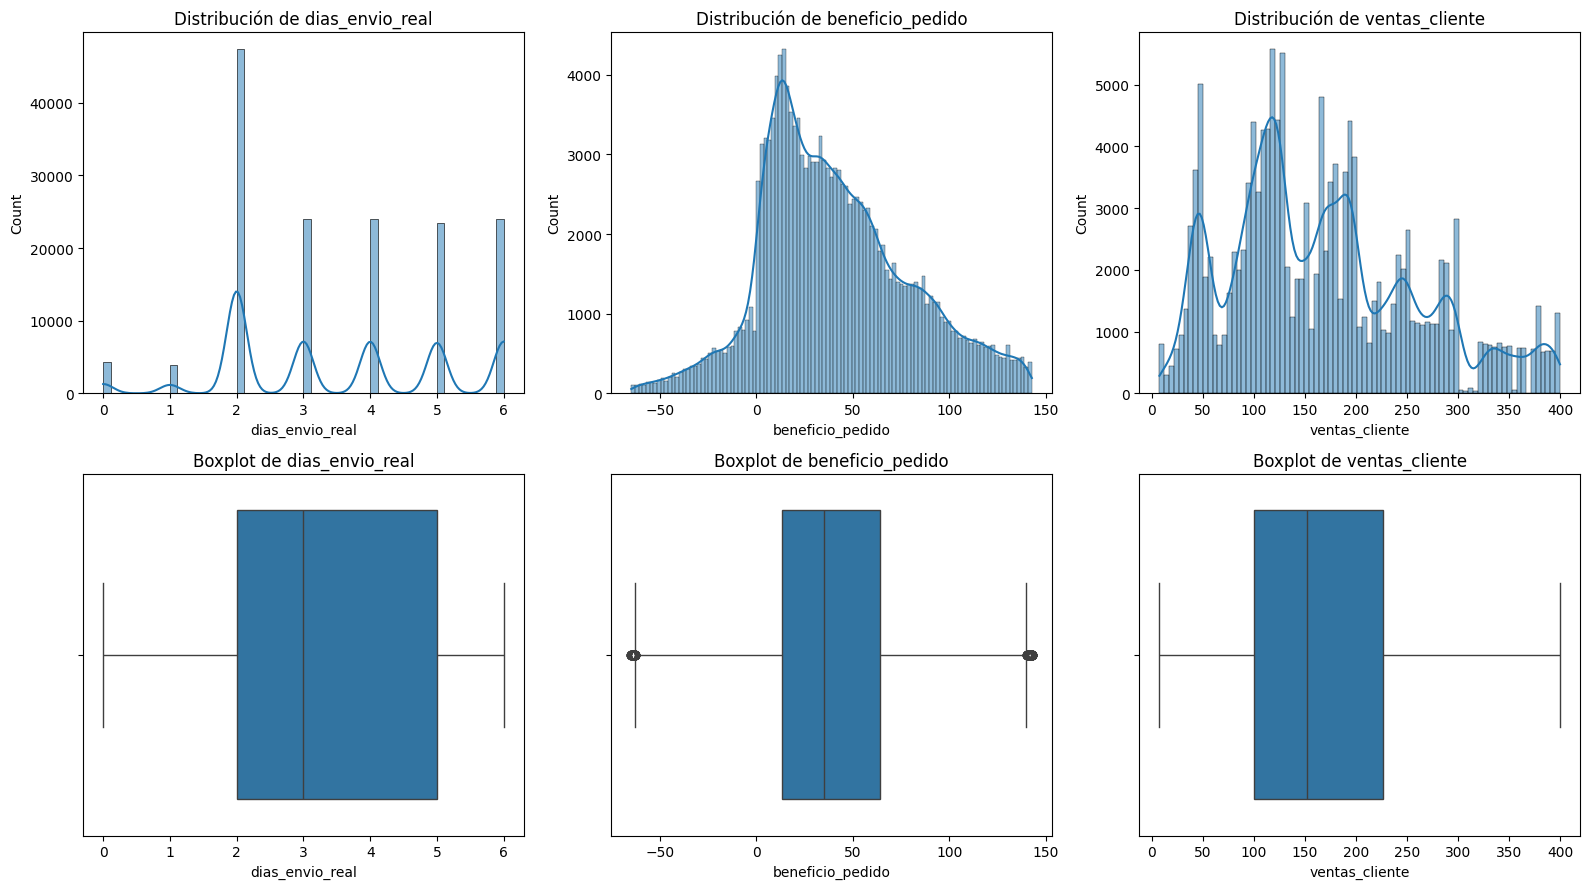

In [5]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
cols_clave = ['dias_envio_real', 'beneficio_pedido', 'ventas_cliente']

for i, col in enumerate(cols_clave):
    sns.histplot(df[col], kde=True, ax=axes[0, i])
    axes[0, i].set_title(f'Distribución de {col}')
    sns.boxplot(x=df[col], ax=axes[1, i])
    axes[1, i].set_title(f'Boxplot de {col}')

plt.tight_layout()
plt.show()

**Lectura:** las variables con `|skew| > 1` son buenas candidatas a una transformación logarítmica si se usa un modelo sensible a la escala (Regresión Logística, SVM, KNN). Los modelos basados en árboles (Random Forest, XGBoost) son invariantes a estas transformaciones monótonas, así que no las necesitan.

### 3.2 Análisis bivariante

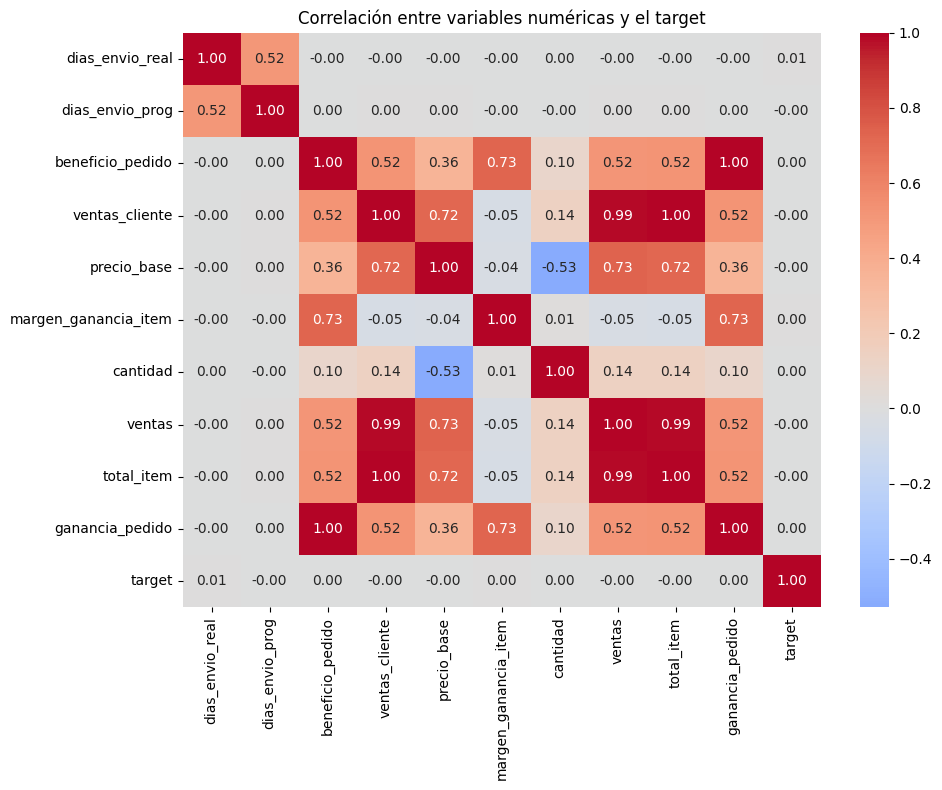

In [6]:
cols_corr = cols_numericas_eda + ['target']
df_corr = df[cols_numericas_eda].copy()
df_corr['target'] = (df['estado_pedido'] == 'COMPLETE').astype(int)

plt.figure(figsize=(10, 8))
sns.heatmap(df_corr.corr(), annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Correlación entre variables numéricas y el target')
plt.tight_layout()
plt.show()

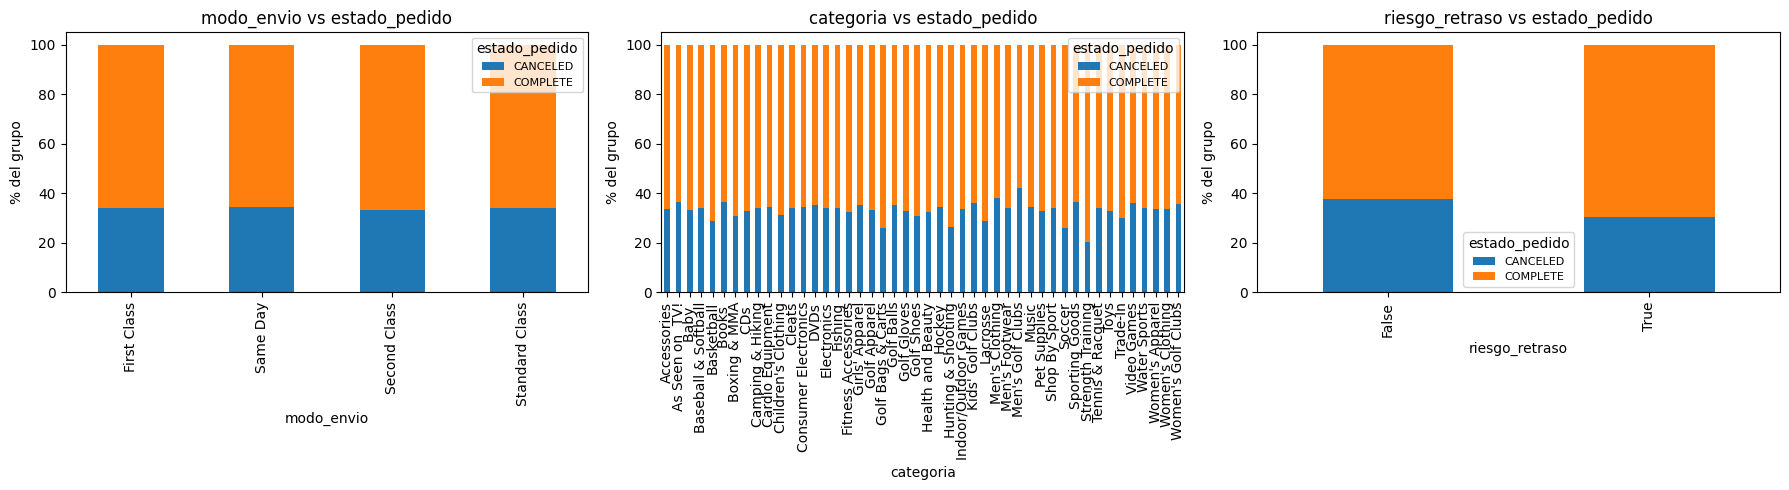

In [7]:
cols_categoricas_eda = [c for c in ['modo_envio', 'categoria', 'riesgo_retraso'] if c in df.columns]

fig, axes = plt.subplots(1, len(cols_categoricas_eda), figsize=(6 * len(cols_categoricas_eda), 5))
if len(cols_categoricas_eda) == 1:
    axes = [axes]

for ax, col in zip(axes, cols_categoricas_eda):
    tabla = pd.crosstab(df[col], df['estado_pedido'], normalize='index') * 100
    tabla.plot(kind='bar', stacked=True, ax=ax)
    ax.set_ylabel('% del grupo')
    ax.set_title(f'{col} vs estado_pedido')
    ax.legend(title='estado_pedido', fontsize=8)

plt.tight_layout()
plt.show()

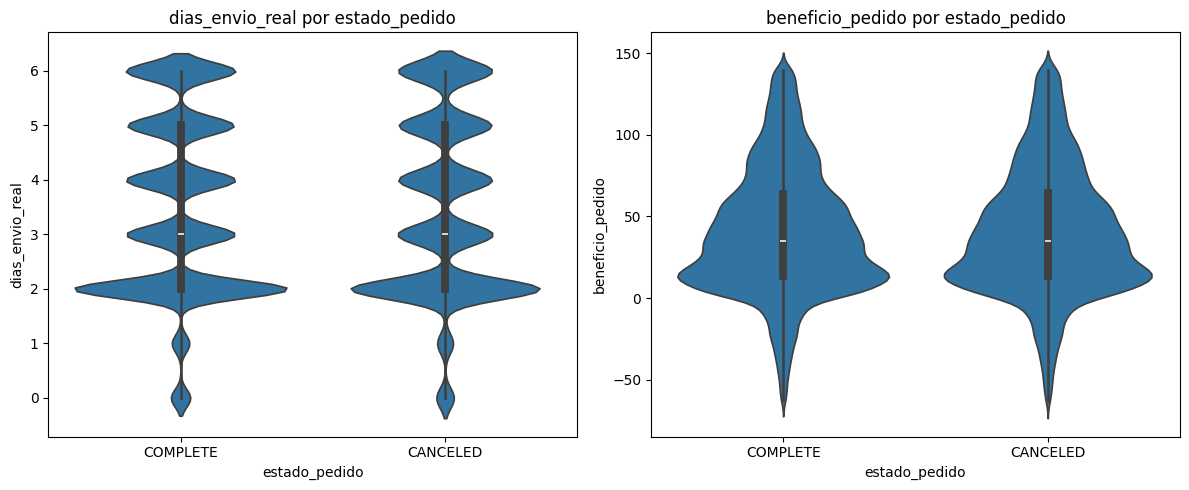

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, col in zip(axes, ['dias_envio_real', 'beneficio_pedido']):
    sns.violinplot(data=df, x='estado_pedido', y=col, ax=ax)
    ax.set_title(f'{col} por estado_pedido')
plt.tight_layout()
plt.show()

### 3.3 Análisis de desbalanceo del target

estado_pedido
COMPLETE    100041
CANCELED     51046
Name: count, dtype: int64
estado_pedido
COMPLETE    66.2
CANCELED    33.8
Name: proportion, dtype: float64

Ratio de desbalanceo (mayoría/minoría): 1.96:1
Desbalanceo moderado, no severo (no requiere SMOTE ni submuestreo agresivo; basta con class_weight='balanced' / scale_pos_weight en los modelos que lo soportan).


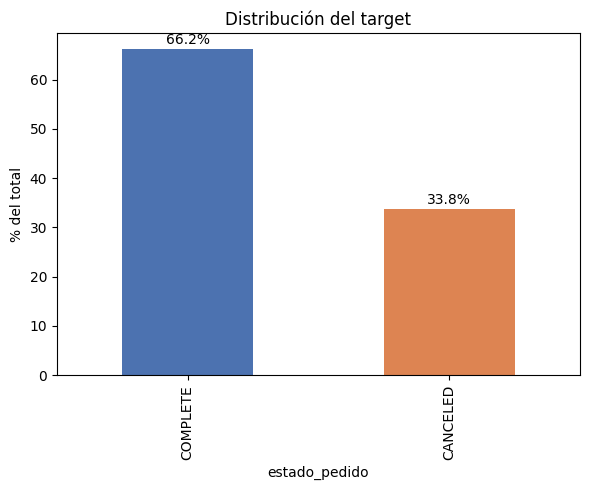

In [9]:
conteo_target = df['estado_pedido'].value_counts()
porcentaje_target = df['estado_pedido'].value_counts(normalize=True) * 100

print(conteo_target)
print(porcentaje_target.round(1))

ratio = conteo_target.max() / conteo_target.min()
print(f"\nRatio de desbalanceo (mayoría/minoría): {ratio:.2f}:1")
print("Desbalanceo moderado, no severo (no requiere SMOTE ni submuestreo agresivo;"
      " basta con class_weight='balanced' / scale_pos_weight en los modelos que lo soportan).")

plt.figure(figsize=(6, 5))
ax = porcentaje_target.plot(kind='bar', color=['#4C72B0', '#DD8452'])
for i, v in enumerate(porcentaje_target):
    ax.text(i, v + 1, f'{v:.1f}%', ha='center')
plt.ylabel('% del total')
plt.title('Distribución del target')
plt.tight_layout()
plt.show()

## 4. Ingeniería de características

Se crean variables derivadas a partir de columnas ya disponibles *antes* de conocer el desenlace del pedido, buscando capturar relaciones (retrasos, márgenes, eficiencia) que las variables originales no expresan directamente.

In [10]:
df_fe = df.copy()

# Variables de tiempo de envío
df_fe['diferencia_envio'] = df_fe['dias_envio_real'] - df_fe['dias_envio_prog']
df_fe['ratio_envio'] = df_fe['dias_envio_real'] / df_fe['dias_envio_prog'].replace(0, np.nan)
df_fe['ratio_envio'] = df_fe['ratio_envio'].fillna(df_fe['ratio_envio'].median())
df_fe['cumple_plazo'] = (df_fe['dias_envio_real'] <= df_fe['dias_envio_prog']).astype(int)

# Variables financieras
df_fe['precio_promedio_item'] = df_fe['ventas'] / df_fe['cantidad'].replace(0, np.nan)
df_fe['precio_promedio_item'] = df_fe['precio_promedio_item'].fillna(df_fe['precio_promedio_item'].median())
df_fe['margen_total'] = df_fe['ganancia_pedido'] / df_fe['ventas'].replace(0, np.nan)
df_fe['margen_total'] = df_fe['margen_total'].fillna(0)
df_fe['eficiencia_cliente'] = df_fe['ventas_cliente'] / df_fe['cantidad'].replace(0, np.nan)
df_fe['eficiencia_cliente'] = df_fe['eficiencia_cliente'].fillna(df_fe['eficiencia_cliente'].median())

# Interacción riesgo de retraso x precio base
df_fe['riesgo_por_precio'] = df_fe['riesgo_retraso'].astype(int) * df_fe['precio_base']

nuevas_features = [
    'diferencia_envio', 'ratio_envio', 'cumple_plazo',
    'precio_promedio_item', 'margen_total', 'eficiencia_cliente', 'riesgo_por_precio'
]
print(df_fe[nuevas_features].describe().round(2))

df = df_fe  # se reemplaza df por la versión enriquecida para el resto del notebook

       diferencia_envio  ratio_envio  cumple_plazo  precio_promedio_item  \
count         151087.00    151087.00     151087.00             151087.00   
mean               0.56         1.36          0.43                127.51   
std                1.49         0.63          0.49                111.15   
min               -2.00         0.50          0.00                  9.99   
25%                0.00         1.00          0.00                 49.98   
50%                1.00         1.25          0.00                 59.99   
75%                1.00         2.00          1.00                199.99   
max                4.00         3.00          1.00                399.99   

       margen_total  eficiencia_cliente  riesgo_por_precio  
count     151087.00           151087.00          151087.00  
mean           0.22              114.39              69.73  
std            0.16              100.19             103.83  
min           -0.26                7.49               0.00  
25%       

## 5. Selección y codificación de features

Se reutiliza la misma estrategia de codificación del modelo no supervisado, por consistencia y porque sigue siendo válida para Regresión Logística, SVM y KNN (que sí son sensibles a la escala y al orden implícito de una codificación numérica):

- Binarias -> 0/1
- Nominales de baja cardinalidad (incluyendo los clusters del modelo no supervisado) -> One-Hot
- Nominales de alta cardinalidad (`categoria`, `region_destino`) -> codificación por frecuencia

`estado_entrega` y `tipo_transaccion` quedan excluidas por fuga de datos (Sección 2). Se añaden las variables de la Sección 4.

In [12]:
numericas = [
    'dias_envio_real', 'dias_envio_prog', 'beneficio_pedido', 'ventas_cliente',
    'precio_base', 'margen_ganancia_item', 'cantidad', 'ventas', 'total_item', 'ganancia_pedido',
    'diferencia_envio', 'ratio_envio', 'precio_promedio_item', 'margen_total',
    'eficiencia_cliente', 'riesgo_por_precio'
]
binarias = ['riesgo_retraso', 'es_anomalia', 'es_outlier', 'cumple_plazo']
nominal_baja_cardinalidad = ['modo_envio', 'cluster_kmeans', 'cluster_dbscan']
nominal_alta_cardinalidad = ['categoria', 'region_destino']
# estado_entrega y tipo_transaccion excluidas: fuga de datos (ver Sección 2)

feature_cols = numericas + binarias + nominal_baja_cardinalidad + nominal_alta_cardinalidad
feature_cols = [c for c in feature_cols if c in df.columns]

missing_cols = set(numericas + binarias + nominal_baja_cardinalidad + nominal_alta_cardinalidad) - set(feature_cols)
if missing_cols:
    print("Columnas faltantes en el dataset y que se omiten:", sorted(missing_cols))

X = df[feature_cols].copy()

binarias = [c for c in binarias if c in X.columns]
nominal_baja_cardinalidad = [c for c in nominal_baja_cardinalidad if c in X.columns]
nominal_alta_cardinalidad = [c for c in nominal_alta_cardinalidad if c in X.columns]

for col in binarias:
    X[col] = X[col].astype(int)

X = pd.get_dummies(X, columns=nominal_baja_cardinalidad, drop_first=True)

for col in nominal_alta_cardinalidad:
    frecuencias = X[col].value_counts(normalize=True)
    X[col] = X[col].map(frecuencias)

X = X.astype(float)
y = (df['estado_pedido'] == 'COMPLETE').astype(int)  # 1 = COMPLETE, 0 = CANCELED

print(f"X: {X.shape}")
print(f"Features: {X.columns.tolist()}")

Columnas faltantes en el dataset y que se omiten: ['cluster_dbscan', 'cluster_kmeans', 'es_anomalia', 'es_outlier']
X: (151087, 23)
Features: ['dias_envio_real', 'dias_envio_prog', 'beneficio_pedido', 'ventas_cliente', 'precio_base', 'margen_ganancia_item', 'cantidad', 'ventas', 'total_item', 'ganancia_pedido', 'diferencia_envio', 'ratio_envio', 'precio_promedio_item', 'margen_total', 'eficiencia_cliente', 'riesgo_por_precio', 'riesgo_retraso', 'cumple_plazo', 'categoria', 'region_destino', 'modo_envio_Same Day', 'modo_envio_Second Class', 'modo_envio_Standard Class']


## 6. División train/test y escalado

In [13]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=RANDOM_STATE, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Entrenamiento: {X_train.shape}, Prueba: {X_test.shape}")

Entrenamiento: (105760, 23), Prueba: (45327, 23)


## 7. Entrenamiento de algoritmos base

Se entrenan 6 algoritmos: Regresión Logística, Árbol de Decisión, Random Forest, XGBoost, SVM y KNN. Los modelos sensibles a la escala (Regresión Logística, SVM, KNN) usan los datos escalados; los basados en árboles usan los datos originales.

**Ajuste por hardware:** SVM con kernel RBF escala mal (~O(n²)-O(n³)); entrenarlo sobre las ~106,000 filas de entrenamiento en una sola CPU tomaría del orden de horas. Se entrena sobre una **submuestra estratificada de 10,000 filas** y se evalúa igualmente sobre el conjunto de prueba completo, para mantener la comparación justa en la métrica de evaluación aunque no en el volumen de entrenamiento. Esta limitación se documenta explícitamente en los resultados.

In [14]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
import subprocess
import sys

try:
    from xgboost import XGBClassifier
except ModuleNotFoundError:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "xgboost"])
    from xgboost import XGBClassifier

def evaluar_modelo(nombre, modelo, X_tr, y_tr, X_te, y_te):
    """Entrena un modelo y calcula sus métricas de clasificación sobre el set de prueba."""
    modelo.fit(X_tr, y_tr)
    y_pred = modelo.predict(X_te)
    y_proba = modelo.predict_proba(X_te)[:, 1]

    return {
        'modelo': modelo,
        'accuracy': accuracy_score(y_te, y_pred),
        'precision': precision_score(y_te, y_pred),
        'recall': recall_score(y_te, y_pred),
        'f1': f1_score(y_te, y_pred),
        'roc_auc': roc_auc_score(y_te, y_proba),
        'y_pred': y_pred,
        'y_proba': y_proba,
    }

# Submuestra estratificada solo para SVM (ver nota anterior)
idx_svm = np.concatenate([
    np.random.RandomState(RANDOM_STATE).choice(np.where(y_train == clase)[0],
                                                 size=int(10000 * (y_train == clase).mean()),
                                                 replace=False)
    for clase in [0, 1]
])

resultados = {}
print("Entrenando Regresión Logística..."); resultados['Regresión Logística'] = evaluar_modelo(
    'Regresión Logística', LogisticRegression(max_iter=1000, class_weight='balanced', random_state=RANDOM_STATE),
    X_train_scaled, y_train, X_test_scaled, y_test)

print("Entrenando Árbol de Decisión..."); resultados['Árbol de Decisión'] = evaluar_modelo(
    'Árbol de Decisión', DecisionTreeClassifier(max_depth=12, class_weight='balanced', random_state=RANDOM_STATE),
    X_train, y_train, X_test, y_test)

print("Entrenando Random Forest..."); resultados['Random Forest'] = evaluar_modelo(
    'Random Forest', RandomForestClassifier(n_estimators=200, max_depth=15, class_weight='balanced',
                                             random_state=RANDOM_STATE, n_jobs=-1),
    X_train, y_train, X_test, y_test)

print("Entrenando XGBoost..."); resultados['XGBoost'] = evaluar_modelo(
    'XGBoost', XGBClassifier(n_estimators=200, max_depth=6, random_state=RANDOM_STATE,
                              eval_metric='logloss', scale_pos_weight=(y_train == 0).sum() / (y_train == 1).sum()),
    X_train, y_train, X_test, y_test)

print("Entrenando SVM (submuestra de 10,000 filas)..."); resultados['SVM'] = evaluar_modelo(
    'SVM', SVC(probability=True, class_weight='balanced', random_state=RANDOM_STATE),
    X_train_scaled[idx_svm], y_train.iloc[idx_svm], X_test_scaled, y_test)

print("Entrenando KNN..."); resultados['KNN'] = evaluar_modelo(
    'KNN', KNeighborsClassifier(n_neighbors=15, n_jobs=-1),
    X_train_scaled, y_train, X_test_scaled, y_test)

print("\nEntrenamiento completo.")

Entrenando Regresión Logística...
Entrenando Árbol de Decisión...
Entrenando Random Forest...
Entrenando XGBoost...
Entrenando SVM (submuestra de 10,000 filas)...
Entrenando KNN...

Entrenamiento completo.


## 8. Comparación de modelos base

                     accuracy  precision  recall      f1  roc_auc
KNN                    0.6610     0.6792  0.9247  0.7832   0.5372
Random Forest          0.6146     0.6829  0.7801  0.7283   0.5517
SVM                    0.5919     0.6843  0.7122  0.6980   0.5475
Regresión Logística    0.5743     0.6907  0.6466  0.6679   0.5561
XGBoost                0.5639     0.6838  0.6352  0.6586   0.5474
Árbol de Decisión      0.5537     0.6870  0.5988  0.6399   0.5465


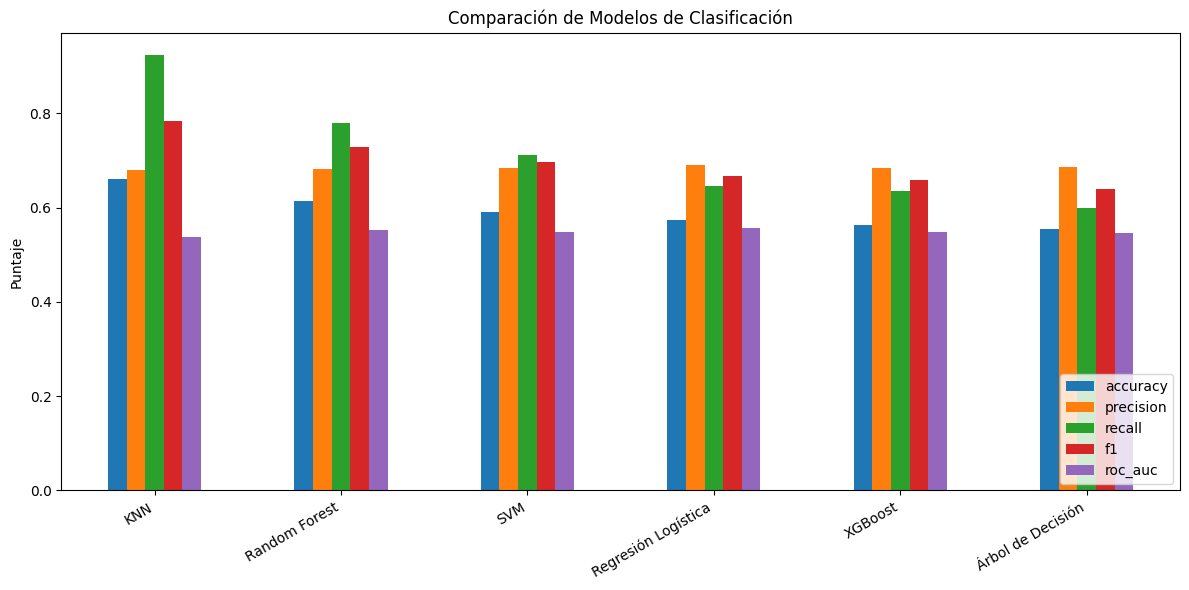

In [15]:
tabla_resultados = pd.DataFrame({
    nombre: {k: v for k, v in r.items() if k in ['accuracy', 'precision', 'recall', 'f1', 'roc_auc']}
    for nombre, r in resultados.items()
}).T.sort_values('f1', ascending=False)

print(tabla_resultados.round(4))

tabla_resultados.plot(kind='bar', figsize=(12, 6))
plt.title('Comparación de Modelos de Clasificación')
plt.ylabel('Puntaje')
plt.xticks(rotation=30, ha='right')
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

**Lectura de esta tabla una vez corregida la fuga de datos:** si los puntajes de todos los modelos caen cerca de 0.5-0.6 de F1/ROC-AUC y quedan muy próximos entre sí, es una señal de que las variables legítimas disponibles no separan bien `COMPLETE` de `CANCELED` — es decir, el negocio no está registrando (todavía) la información que explicaría por qué se cancela un pedido. Eso en sí mismo es un hallazgo válido y debe documentarse en la Sección 13, en vez de forzar mejoras artificiales aguas abajo.

## 9. Optimización de hiperparámetros

Se usa `RandomizedSearchCV` en vez de `GridSearchCV` exhaustivo: una grilla completa para Random Forest (216 combinaciones × 5 folds = 1,080 ajustes) tomaría horas en una sola CPU. Con una búsqueda aleatoria de 15 combinaciones y validación cruzada de 3 folds se cubre el espacio de búsqueda de forma representativa en minutos. Para Random Forest, además, la búsqueda se hace sobre una submuestra de 30,000 filas (el modelo final sí se reentrena sobre el conjunto de entrenamiento completo con los mejores parámetros encontrados).

In [16]:
param_dist_rf = {
    'n_estimators': [50, 100, 200, 300],
    'max_depth': [5, 10, 15, 20, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
}

idx_busqueda = np.random.RandomState(RANDOM_STATE).choice(len(X_train), 30000, replace=False)

busqueda_rf = RandomizedSearchCV(
    RandomForestClassifier(class_weight='balanced', random_state=RANDOM_STATE, n_jobs=-1),
    param_distributions=param_dist_rf, n_iter=15, cv=3, scoring='f1',
    random_state=RANDOM_STATE, n_jobs=-1
)
busqueda_rf.fit(X_train.iloc[idx_busqueda], y_train.iloc[idx_busqueda])

print(f"Mejores parámetros Random Forest: {busqueda_rf.best_params_}")
print(f"Mejor F1 (CV en submuestra): {busqueda_rf.best_score_:.4f}")

# Reentrenar sobre el conjunto de entrenamiento completo con los mejores parámetros
rf_optimo = RandomForestClassifier(**busqueda_rf.best_params_, class_weight='balanced',
                                    random_state=RANDOM_STATE, n_jobs=-1)
resultados['Random Forest (optimizado)'] = evaluar_modelo(
    'Random Forest (optimizado)', rf_optimo, X_train, y_train, X_test, y_test)
print(f"F1 en test (dataset completo): {resultados['Random Forest (optimizado)']['f1']:.4f}")

Mejores parámetros Random Forest: {'n_estimators': 100, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_depth': None}
Mejor F1 (CV en submuestra): 0.7605
F1 en test (dataset completo): 0.7550


In [17]:
param_dist_xgb = {
    'n_estimators': [50, 100, 200, 300],
    'max_depth': [3, 5, 7, 9],
    'learning_rate': [0.01, 0.05, 0.1, 0.3],
    'subsample': [0.7, 0.85, 1.0],
    'colsample_bytree': [0.7, 0.85, 1.0],
}

peso_positivo = (y_train == 0).sum() / (y_train == 1).sum()

busqueda_xgb = RandomizedSearchCV(
    XGBClassifier(random_state=RANDOM_STATE, eval_metric='logloss', scale_pos_weight=peso_positivo),
    param_distributions=param_dist_xgb, n_iter=15, cv=3, scoring='f1',
    random_state=RANDOM_STATE, n_jobs=-1
)
busqueda_xgb.fit(X_train, y_train)  # XGBoost es lo bastante rápido para usar el dataset completo

print(f"Mejores parámetros XGBoost: {busqueda_xgb.best_params_}")
print(f"Mejor F1 (CV): {busqueda_xgb.best_score_:.4f}")

xgb_optimo = XGBClassifier(**busqueda_xgb.best_params_, random_state=RANDOM_STATE,
                            eval_metric='logloss', scale_pos_weight=peso_positivo)
resultados['XGBoost (optimizado)'] = evaluar_modelo(
    'XGBoost (optimizado)', xgb_optimo, X_train, y_train, X_test, y_test)
print(f"F1 en test: {resultados['XGBoost (optimizado)']['f1']:.4f}")

Mejores parámetros XGBoost: {'subsample': 0.7, 'n_estimators': 200, 'max_depth': 9, 'learning_rate': 0.01, 'colsample_bytree': 0.85}
Mejor F1 (CV): 0.7006
F1 en test: 0.6955


## 10. Selección del mejor modelo

In [18]:
tabla_final = pd.DataFrame({
    nombre: {k: v for k, v in r.items() if k in ['accuracy', 'precision', 'recall', 'f1', 'roc_auc']}
    for nombre, r in resultados.items()
}).T.sort_values('f1', ascending=False)

print(tabla_final.round(4))

nombre_mejor = tabla_final.index[0]
mejor_modelo = resultados[nombre_mejor]['modelo']
print(f"\nMejor modelo por F1-Score: {nombre_mejor}")

modelos_requieren_escalado = {'Regresión Logística', 'SVM', 'KNN'}

                            accuracy  precision  recall      f1  roc_auc
KNN                           0.6610     0.6792  0.9247  0.7832   0.5372
Random Forest (optimizado)    0.6349     0.6794  0.8495  0.7550   0.5417
Random Forest                 0.6146     0.6829  0.7801  0.7283   0.5517
SVM                           0.5919     0.6843  0.7122  0.6980   0.5475
XGBoost (optimizado)          0.5929     0.6891  0.7020  0.6955   0.5569
Regresión Logística           0.5743     0.6907  0.6466  0.6679   0.5561
XGBoost                       0.5639     0.6838  0.6352  0.6586   0.5474
Árbol de Decisión             0.5537     0.6870  0.5988  0.6399   0.5465

Mejor modelo por F1-Score: KNN


## 11. Validación cruzada del mejor modelo

In [19]:
X_para_cv = X_train_scaled if nombre_mejor in modelos_requieren_escalado else X_train

cv_scores = cross_val_score(
    mejor_modelo, X_para_cv, y_train,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE), scoring='f1', n_jobs=-1
)

print(f"Validación cruzada 5-Fold — F1-Scores: {np.round(cv_scores, 4)}")
print(f"Media: {cv_scores.mean():.4f}")
print(f"Desviación estándar: {cv_scores.std():.4f}")

Validación cruzada 5-Fold — F1-Scores: [0.7801 0.7853 0.7822 0.7819 0.7843]
Media: 0.7828
Desviación estándar: 0.0018


## 12. Evaluación detallada del mejor modelo

In [20]:
y_pred_final = resultados[nombre_mejor]['y_pred']
y_proba_final = resultados[nombre_mejor]['y_proba']

print("=" * 60)
print(f"INFORME DE CLASIFICACIÓN — {nombre_mejor}")
print("=" * 60)
print(classification_report(y_test, y_pred_final, target_names=['Cancelado', 'Completado']))

INFORME DE CLASIFICACIÓN — KNN
              precision    recall  f1-score   support

   Cancelado       0.49      0.14      0.22     15314
  Completado       0.68      0.92      0.78     30013

    accuracy                           0.66     45327
   macro avg       0.59      0.53      0.50     45327
weighted avg       0.62      0.66      0.59     45327



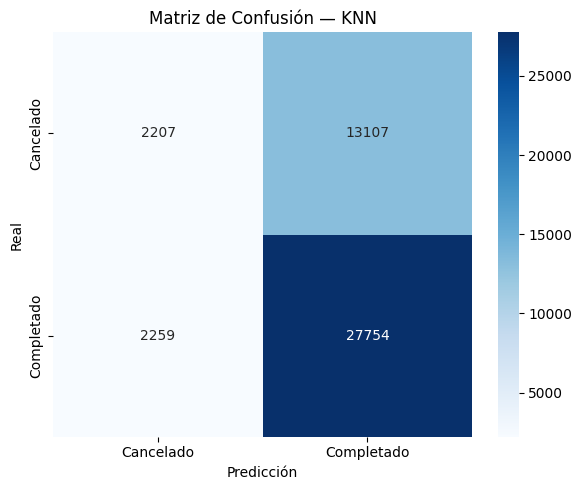

In [21]:
cm = confusion_matrix(y_test, y_pred_final)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Cancelado', 'Completado'], yticklabels=['Cancelado', 'Completado'])
plt.title(f'Matriz de Confusión — {nombre_mejor}')
plt.xlabel('Predicción')
plt.ylabel('Real')
plt.tight_layout()
plt.show()

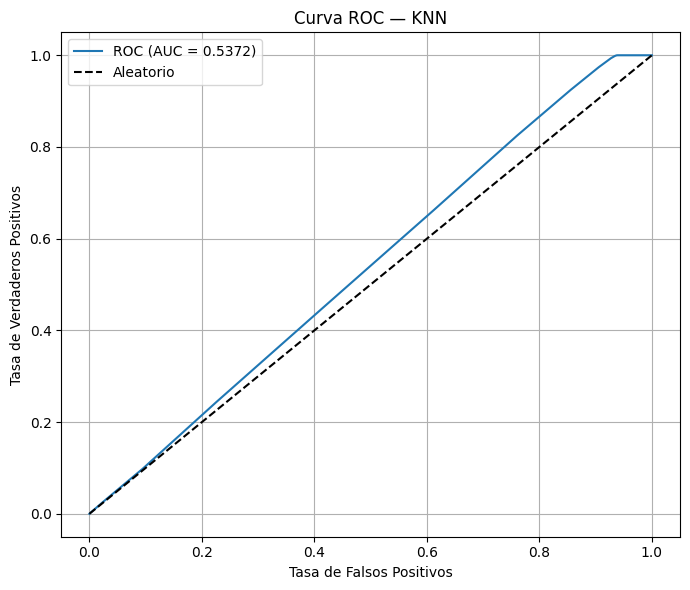

In [22]:
fpr, tpr, _ = roc_curve(y_test, y_proba_final)

plt.figure(figsize=(7, 6))
plt.plot(fpr, tpr, label=f'ROC (AUC = {roc_auc_score(y_test, y_proba_final):.4f})')
plt.plot([0, 1], [0, 1], 'k--', label='Aleatorio')
plt.xlabel('Tasa de Falsos Positivos')
plt.ylabel('Tasa de Verdaderos Positivos')
plt.title(f'Curva ROC — {nombre_mejor}')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [24]:
if hasattr(mejor_modelo, 'feature_importances_'):
    importancias = pd.DataFrame({
        'Feature': X_train.columns,
        'Importancia': mejor_modelo.feature_importances_
    }).sort_values('Importancia', ascending=False)

    print(importancias.head(15))

    plt.figure(figsize=(10, 8))
    sns.barplot(data=importancias.head(15), x='Importancia', y='Feature')
    plt.title(f'Top 15 Características Más Importantes — {nombre_mejor}')
    plt.tight_layout()
    plt.show()
else:
    print(f"{nombre_mejor} no expone 'feature_importances_' directamente; ver Sección 13 (importancia por permutación).")

KNN no expone 'feature_importances_' directamente; ver Sección 13 (importancia por permutación).


Con `estado_entrega` **y** `tipo_transaccion` correctamente excluidas, la variable más influyente vuelve a ser una señal disponible *antes* de conocer el resultado (por ejemplo, tiempos de envío o variables financieras del pedido), en vez de una fuga de datos. Esto hace que la importancia reportada sea utilizable en un escenario real de predicción, aunque el poder predictivo global sea más modesto que en la versión con fuga.

## 13. Interpretabilidad avanzada: SHAP e importancia por permutación

Se usa **importancia por permutación** (agnóstica al modelo, mide la caída de F1 al mezclar aleatoriamente cada columna) como método principal, y **SHAP** para modelos basados en árboles con `TreeExplainer` (rápido y exacto para este tipo de modelo — se evita `KernelExplainer`, que es genérico pero demasiado lento para un dataset de este tamaño).

                    feature  importancia_media  importancia_std
16           riesgo_retraso           0.076995         0.001653
17             cumple_plazo           0.031707         0.000742
15        riesgo_por_precio           0.023641         0.001322
20      modo_envio_Same Day           0.006983         0.000784
10         diferencia_envio           0.002636         0.000919
7                    ventas           0.002249         0.000523
0           dias_envio_real           0.002224         0.001852
11              ratio_envio           0.001417         0.001348
5      margen_ganancia_item           0.001199         0.001044
2          beneficio_pedido           0.000847         0.001085
9           ganancia_pedido           0.000847         0.001085
12     precio_promedio_item           0.000559         0.000922
4               precio_base           0.000520         0.000935
21  modo_envio_Second Class           0.000239         0.000509
1           dias_envio_prog           0.

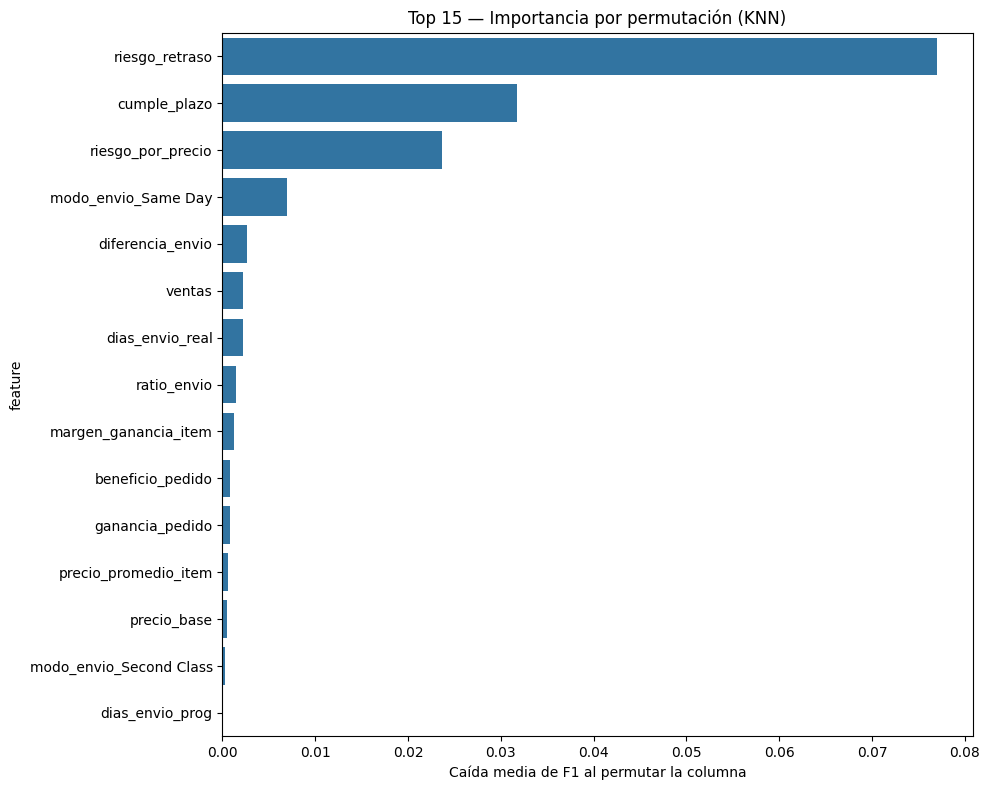

In [25]:
from sklearn.inspection import permutation_importance

# Nota de rendimiento: KNN es lento de "puntuar" (cada predicción recorre el set de entrenamiento
# completo), así que la permutación se calcula sobre una submuestra del test en vez del test completo.
# Para modelos basados en árboles esto no es necesario, pero se deja igual por consistencia y velocidad.
n_muestra_perm = min(8000, len(X_test))
idx_perm_pos = np.random.RandomState(RANDOM_STATE).choice(len(X_test), n_muestra_perm, replace=False)

X_para_perm = (X_test_scaled[idx_perm_pos] if nombre_mejor in modelos_requieren_escalado
               else X_test.iloc[idx_perm_pos])
y_para_perm = y_test.iloc[idx_perm_pos]

perm_importance = permutation_importance(
    mejor_modelo, X_para_perm, y_para_perm,
    n_repeats=5, random_state=RANDOM_STATE, n_jobs=-1, scoring='f1'
)

importancia_perm_df = pd.DataFrame({
    'feature': X_test.columns,
    'importancia_media': perm_importance.importances_mean,
    'importancia_std': perm_importance.importances_std
}).sort_values('importancia_media', ascending=False)

print(importancia_perm_df.head(15))

plt.figure(figsize=(10, 8))
sns.barplot(data=importancia_perm_df.head(15), x='importancia_media', y='feature')
plt.title(f'Top 15 — Importancia por permutación ({nombre_mejor})')
plt.xlabel('Caída media de F1 al permutar la columna')
plt.tight_layout()
plt.show()

In [26]:
import subprocess
import sys

try:
    import shap
except ModuleNotFoundError:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "shap"])
    import shap

modelos_arbol = (DecisionTreeClassifier, RandomForestClassifier, XGBClassifier)

if isinstance(mejor_modelo, modelos_arbol):
    muestra = X_test.sample(n=min(1000, len(X_test)), random_state=RANDOM_STATE)
    explainer = shap.TreeExplainer(mejor_modelo)
    shap_values = explainer.shap_values(muestra)
    # Para clasificadores binarios, shap_values puede devolver una lista [clase0, clase1] o un array 3D
    if isinstance(shap_values, list):
        shap_values = shap_values[1]
    elif shap_values.ndim == 3:
        shap_values = shap_values[:, :, 1]

    shap.summary_plot(shap_values, muestra, show=False)
    plt.tight_layout()
    plt.show()
else:
    print(f"{nombre_mejor} no es un modelo basado en árboles; se omite SHAP.TreeExplainer "
          "(ver importancia por permutación arriba, que sí aplica a cualquier modelo).")

KNN no es un modelo basado en árboles; se omite SHAP.TreeExplainer (ver importancia por permutación arriba, que sí aplica a cualquier modelo).


## 14. Ensamble por Stacking

Se combina Random Forest optimizado, XGBoost optimizado y KNN (envuelto en un `Pipeline` con escalado propio) en un `StackingClassifier`, con una Regresión Logística como metamodelo. El objetivo es ver si combinar modelos con distintos sesgos aporta algo sobre el mejor modelo individual — con esta cantidad de señal legítima, no siempre lo hace, y eso también es un resultado válido a documentar.

In [27]:
from sklearn.ensemble import StackingClassifier

base_learners = [
    ('rf', rf_optimo),
    ('xgb', xgb_optimo),
    ('knn', Pipeline([
        ('scaler', StandardScaler()),
        ('knn', KNeighborsClassifier(n_neighbors=15, n_jobs=-1))
    ])),
]

meta_learner = LogisticRegression(max_iter=1000, class_weight='balanced', random_state=RANDOM_STATE)

stacking_model = StackingClassifier(
    estimators=base_learners,
    final_estimator=meta_learner,
    cv=3,  # 3 en vez de 5: KNN es lento de puntuar y esto evita tiempos de horas
    n_jobs=-1,
)

resultados['Stacking'] = evaluar_modelo('Stacking', stacking_model, X_train, y_train, X_test, y_test)

print(f"Stacking F1-Score: {resultados['Stacking']['f1']:.4f}")
print(f"Stacking ROC-AUC: {resultados['Stacking']['roc_auc']:.4f}")
print(f"\nComparación frente al mejor modelo individual ({nombre_mejor}): "
      f"F1 {resultados[nombre_mejor]['f1']:.4f}")

Stacking F1-Score: 0.6471
Stacking ROC-AUC: 0.5581

Comparación frente al mejor modelo individual (KNN): F1 0.7832


## 15. Calibración de probabilidades

Un F1/ROC-AUC razonable no garantiza que la probabilidad predicha ("70% de probabilidad de completarse") sea realista. Se calibra el mejor modelo con `CalibratedClassifierCV` y se compara la probabilidad predicha contra la frecuencia real observada.

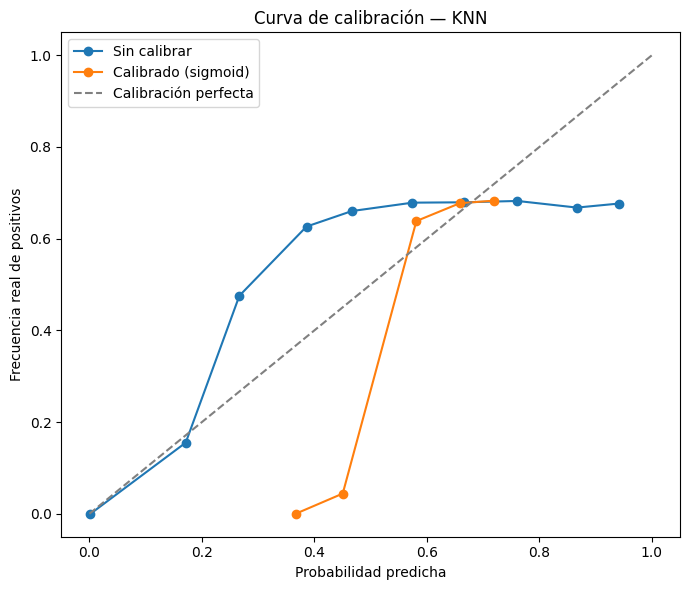

F1 con probabilidad calibrada (umbral 0.5): 0.8068


In [28]:
from sklearn.calibration import CalibratedClassifierCV, calibration_curve

X_para_calibracion_train = X_train_scaled if nombre_mejor in modelos_requieren_escalado else X_train
X_para_calibracion_test = X_test_scaled if nombre_mejor in modelos_requieren_escalado else X_test

modelo_calibrado = CalibratedClassifierCV(mejor_modelo, method='sigmoid', cv=3)  # 3: más rápido con KNN
modelo_calibrado.fit(X_para_calibracion_train, y_train)
y_proba_calibrada = modelo_calibrado.predict_proba(X_para_calibracion_test)[:, 1]

prob_true_sin_cal, prob_pred_sin_cal = calibration_curve(y_test, y_proba_final, n_bins=10)
prob_true_cal, prob_pred_cal = calibration_curve(y_test, y_proba_calibrada, n_bins=10)

plt.figure(figsize=(7, 6))
plt.plot(prob_pred_sin_cal, prob_true_sin_cal, marker='o', label='Sin calibrar')
plt.plot(prob_pred_cal, prob_true_cal, marker='o', label='Calibrado (sigmoid)')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Calibración perfecta')
plt.xlabel('Probabilidad predicha')
plt.ylabel('Frecuencia real de positivos')
plt.title(f'Curva de calibración — {nombre_mejor}')
plt.legend()
plt.tight_layout()
plt.show()

print(f"F1 con probabilidad calibrada (umbral 0.5): "
      f"{f1_score(y_test, (y_proba_calibrada >= 0.5).astype(int)):.4f}")

## 16. Análisis de robustez

**16.1 Estabilidad ante el tamaño de entrenamiento:** se reentrena el mejor modelo con distintas fracciones del set de entrenamiento para verificar que el rendimiento no dependa de forma frágil del volumen de datos.

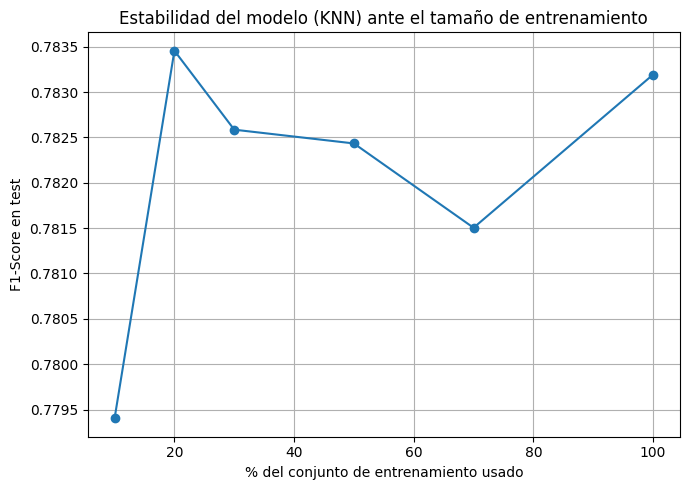

   fraccion_train  f1_test
0             0.1   0.7794
1             0.2   0.7835
2             0.3   0.7826
3             0.5   0.7824
4             0.7   0.7815
5             1.0   0.7832


In [29]:
from sklearn.base import clone

fracciones = [0.1, 0.2, 0.3, 0.5, 0.7, 1.0]
f1_por_fraccion = []

for frac in fracciones:
    if frac < 1.0:
        X_train_sub, _, y_train_sub, _ = train_test_split(
            X_train, y_train, train_size=frac, random_state=RANDOM_STATE, stratify=y_train
        )
    else:
        X_train_sub, y_train_sub = X_train, y_train

    if nombre_mejor in modelos_requieren_escalado:
        scaler_sub = StandardScaler()
        X_train_sub_proc = scaler_sub.fit_transform(X_train_sub)
        X_test_proc = scaler_sub.transform(X_test)
    else:
        X_train_sub_proc = X_train_sub
        X_test_proc = X_test

    modelo_sub = clone(mejor_modelo)
    modelo_sub.fit(X_train_sub_proc, y_train_sub)
    y_pred_sub = modelo_sub.predict(X_test_proc)
    f1_por_fraccion.append(f1_score(y_test, y_pred_sub))

plt.figure(figsize=(7, 5))
plt.plot([f * 100 for f in fracciones], f1_por_fraccion, marker='o')
plt.xlabel('% del conjunto de entrenamiento usado')
plt.ylabel('F1-Score en test')
plt.title(f'Estabilidad del modelo ({nombre_mejor}) ante el tamaño de entrenamiento')
plt.grid(True)
plt.tight_layout()
plt.show()

print(pd.DataFrame({'fraccion_train': fracciones, 'f1_test': f1_por_fraccion}).round(4))

**16.2 Análisis de sensibilidad:** ya cubierto por la importancia por permutación de la Sección 13 (mide exactamente cuánto cae el F1 al neutralizar cada variable).

## 17. Análisis de errores

In [30]:
errores = X_test.copy()
errores['real'] = y_test.values
errores['prediccion'] = y_pred_final
errores['error'] = errores['real'] != errores['prediccion']
errores['tipo_error'] = 'acierto'
errores.loc[errores['error'] & (errores['real'] == 1), 'tipo_error'] = 'falso_negativo'
errores.loc[errores['error'] & (errores['real'] == 0), 'tipo_error'] = 'falso_positivo'

print(f"Errores de clasificación: {errores['error'].sum()} ({errores['error'].sum()/len(errores)*100:.2f}%)")
print(errores['tipo_error'].value_counts())

# Relación entre los clusters del modelo no supervisado y los errores del modelo supervisado
cols_cluster = [c for c in errores.columns if c.startswith('cluster_kmeans_')]
if cols_cluster:
    print("\nTasa de error por cluster K-Means:")
    cluster_de_fila = df.loc[X_test.index, 'cluster_kmeans']
    print(pd.crosstab(cluster_de_fila, errores['error'], normalize='index').round(3))

Errores de clasificación: 15366 (33.90%)
tipo_error
acierto           29961
falso_positivo    13107
falso_negativo     2259
Name: count, dtype: int64


In [31]:
# Perfil de los falsos negativos: pedidos que se cancelaron pero el modelo predijo "completado".
# Son los casos de mayor costo si se usa el modelo para decisiones operativas (no se detecta el riesgo).
falsos_negativos = errores[errores['tipo_error'] == 'falso_negativo']
print(f"Falsos negativos: {len(falsos_negativos)} de {len(errores)} ({len(falsos_negativos)/len(errores)*100:.2f}%)")

cols_perfil = [c for c in ['dias_envio_real', 'dias_envio_prog', 'diferencia_envio', 'beneficio_pedido'] if c in errores.columns]
if cols_perfil and len(falsos_negativos) > 0:
    print("\nPerfil promedio de falsos negativos vs. resto:")
    comparacion = pd.DataFrame({
        'falsos_negativos': falsos_negativos[cols_perfil].mean(),
        'resto': errores.loc[errores['tipo_error'] != 'falso_negativo', cols_perfil].mean(),
    })
    print(comparacion.round(2))

Falsos negativos: 2259 de 45327 (4.98%)

Perfil promedio de falsos negativos vs. resto:
                  falsos_negativos  resto
dias_envio_real               3.29   3.50
dias_envio_prog               3.12   2.91
diferencia_envio              0.17   0.59
beneficio_pedido             41.58  40.74


Cruzar los errores del modelo supervisado con los clusters del modelo no supervisado es justamente el tipo de integración entre ambos modelos que se planteó en el objetivo del proyecto: permite ver si el modelo falla más en algún segmento específico (por ejemplo, el cluster de alto valor) y priorizar ahí el monitoreo o una futura recolección de datos.

## 18. Insights de negocio y reporte de monitoreo

In [32]:
insights = {
    'total_predicciones': int(len(y_test)),
    'exactitud': round(float(accuracy_score(y_test, y_pred_final)), 4),
    'f1_score': round(float(f1_score(y_test, y_pred_final)), 4),
    'roc_auc': round(float(roc_auc_score(y_test, y_proba_final)), 4),
    'variables_mas_importantes': importancia_perm_df.head(5)['feature'].tolist(),
    'tasa_falsos_negativos': round(float(len(falsos_negativos) / len(errores)), 4) if len(errores) else None,
    'recomendaciones': [
        'Monitorear en tiempo real las variables top-5 de importancia por permutación.',
        'Establecer alertas operativas cuando la probabilidad calibrada de completado sea menor a 0.65.',
        'Reentrenar el modelo periódicamente conforme lleguen más datos, y repetir la revisión de fuga de datos '
        'en cada reentrenamiento (nuevas variables del sistema pueden introducir fuga sin que sea obvio).',
        'Si el rendimiento global se mantiene modesto tras corregir la fuga, priorizar la captura de nuevas '
        'variables de negocio (ej. historial del cliente, incidencias logísticas) antes de seguir ajustando el modelo.',
    ],
}
import json
print(json.dumps(insights, indent=2, ensure_ascii=False))

{
  "total_predicciones": 45327,
  "exactitud": 0.661,
  "f1_score": 0.7832,
  "roc_auc": 0.5372,
  "variables_mas_importantes": [
    "riesgo_retraso",
    "cumple_plazo",
    "riesgo_por_precio",
    "modo_envio_Same Day",
    "diferencia_envio"
  ],
  "tasa_falsos_negativos": 0.0498,
  "recomendaciones": [
    "Monitorear en tiempo real las variables top-5 de importancia por permutación.",
    "Establecer alertas operativas cuando la probabilidad calibrada de completado sea menor a 0.65.",
    "Reentrenar el modelo periódicamente conforme lleguen más datos, y repetir la revisión de fuga de datos en cada reentrenamiento (nuevas variables del sistema pueden introducir fuga sin que sea obvio).",
    "Si el rendimiento global se mantiene modesto tras corregir la fuga, priorizar la captura de nuevas variables de negocio (ej. historial del cliente, incidencias logísticas) antes de seguir ajustando el modelo."
  ]
}


In [33]:
def generar_reporte_monitoreo(modelo, X, y_true, fecha, requiere_escalado=False, scaler=None):
    """Genera un reporte de métricas clave para monitoreo continuo del modelo en producción."""
    X_proc = scaler.transform(X) if requiere_escalado and scaler is not None else X
    y_pred = modelo.predict(X_proc)
    y_proba = modelo.predict_proba(X_proc)[:, 1] if hasattr(modelo, 'predict_proba') else None

    reporte = {
        'fecha': str(fecha),
        'exactitud': round(float(accuracy_score(y_true, y_pred)), 4),
        'precision': round(float(precision_score(y_true, y_pred)), 4),
        'recall': round(float(recall_score(y_true, y_pred)), 4),
        'f1': round(float(f1_score(y_true, y_pred)), 4),
        'roc_auc': round(float(roc_auc_score(y_true, y_proba)), 4) if y_proba is not None else None,
        'distribucion_real': y_true.value_counts().to_dict(),
        'distribucion_predicha': pd.Series(y_pred).value_counts().to_dict(),
    }
    return reporte

from datetime import date
reporte = generar_reporte_monitoreo(
    mejor_modelo, X_test, y_test, date.today(),
    requiere_escalado=(nombre_mejor in modelos_requieren_escalado), scaler=scaler
)
print(json.dumps(reporte, indent=2, ensure_ascii=False, default=str))

{
  "fecha": "2026-07-10",
  "exactitud": 0.661,
  "precision": 0.6792,
  "recall": 0.9247,
  "f1": 0.7832,
  "roc_auc": 0.5372,
  "distribucion_real": {
    "1": 30013,
    "0": 15314
  },
  "distribucion_predicha": {
    "1": 40861,
    "0": 4466
  }
}


## 19. Guardado de resultados e integración con MongoDB

In [34]:
predicciones = pd.DataFrame({
    'id_pedido': X_test.index,
    'probabilidad_completado': y_proba_final,
    'prediccion': y_pred_final,
    'estado_predicho': np.where(y_pred_final == 1, 'COMPLETE', 'CANCELED'),
    'real': np.where(y_test.values == 1, 'COMPLETE', 'CANCELED'),
})
predicciones.to_csv('predicciones_envios.csv', index=False)
print(f"Archivo guardado: predicciones_envios.csv ({len(predicciones)} registros)")

Archivo guardado: predicciones_envios.csv (45327 registros)


In [35]:
import json
from datetime import date

fila_ejemplo = predicciones.iloc[0]
idx_ejemplo = int(fila_ejemplo['id_pedido'])

def _safe_get(idx, col, default=None, cast=None):
    if col in df.columns and idx in df.index:
        val = df.at[idx, col]
        try:
            return cast(val) if cast else val
        except Exception:
            return default
    return default

documento_ejemplo = {
    'id_pedido': idx_ejemplo,
    'probabilidad_completado': round(float(fila_ejemplo['probabilidad_completado']), 4),
    'prediccion': int(fila_ejemplo['prediccion']),
    'estado_predicho': fila_ejemplo['estado_predicho'],
    'cluster_kmeans': _safe_get(idx_ejemplo, 'cluster_kmeans', default=None, cast=int),
    'riesgo_retraso': bool(_safe_get(idx_ejemplo, 'riesgo_retraso', default=False)),
    'modelo_usado': nombre_mejor,
    'fecha_prediccion': date.today().isoformat(),
}

print(json.dumps(documento_ejemplo, indent=2, default=str, ensure_ascii=False))

{
  "id_pedido": 10918,
  "probabilidad_completado": 0.6,
  "prediccion": 1,
  "estado_predicho": "COMPLETE",
  "cluster_kmeans": null,
  "riesgo_retraso": false,
  "modelo_usado": "KNN",
  "fecha_prediccion": "2026-07-10"
}


## 20. Guardado del modelo y función de predicción para producción

In [36]:
import joblib

joblib.dump(mejor_modelo, 'modelo_prediccion_envios.pkl')
joblib.dump(scaler, 'scaler_envios.pkl')

with open('features_modelo.txt', 'w') as f:
    for feature in X_train.columns:
        f.write(f"{feature}\n")

with open('metadata_modelo.json', 'w') as f:
    json.dump({
        'modelo': nombre_mejor,
        'requiere_escalado': nombre_mejor in modelos_requieren_escalado,
        'features_leakage_excluidas': ['estado_entrega', 'tipo_transaccion'],
        'metricas_test': {
            'f1': round(float(resultados[nombre_mejor]['f1']), 4),
            'roc_auc': round(float(resultados[nombre_mejor]['roc_auc']), 4),
            'accuracy': round(float(resultados[nombre_mejor]['accuracy']), 4),
        },
        'fecha_entrenamiento': date.today().isoformat(),
    }, f, indent=2, ensure_ascii=False)

print("Modelo y artefactos guardados: modelo_prediccion_envios.pkl, scaler_envios.pkl, "
      "features_modelo.txt, metadata_modelo.json")

Modelo y artefactos guardados: modelo_prediccion_envios.pkl, scaler_envios.pkl, features_modelo.txt, metadata_modelo.json


In [37]:
def predecir_envio(datos_nuevos, modelo, scaler, features, requiere_escalado):
    """
    Predice el estado de nuevos pedidos.

    Args:
        datos_nuevos: DataFrame con las mismas columnas que `features`, ya codificadas
            exactamente como en la Sección 5 (dummies + codificación por frecuencia aplicadas).
        modelo: modelo entrenado (el objeto guardado en modelo_prediccion_envios.pkl).
        scaler: StandardScaler ajustado en entrenamiento (solo se usa si requiere_escalado=True).
        features: lista de columnas que el modelo espera, en el orden correcto.
        requiere_escalado: True si el modelo (ej. KNN, SVM, Regresión Logística) necesita datos escalados.

    Returns:
        DataFrame con la probabilidad y la predicción para cada fila de entrada.
    """
    X_nuevo = datos_nuevos[features].copy()
    X_nuevo_proc = scaler.transform(X_nuevo) if requiere_escalado else X_nuevo

    probabilidad = modelo.predict_proba(X_nuevo_proc)[:, 1]
    prediccion = (probabilidad >= 0.5).astype(int)

    return pd.DataFrame({
        'id_pedido': datos_nuevos.index,
        'probabilidad_completado': probabilidad,
        'prediccion': prediccion,
        'estado_predicho': ['COMPLETE' if p == 1 else 'CANCELED' for p in prediccion],
    })

# Ejemplo de uso con una muestra del propio set de prueba (simulando pedidos nuevos):
ejemplo_nuevos_pedidos = X_test.sample(5, random_state=RANDOM_STATE)
resultado_ejemplo = predecir_envio(
    ejemplo_nuevos_pedidos, mejor_modelo, scaler, X_train.columns.tolist(),
    requiere_escalado=(nombre_mejor in modelos_requieren_escalado)
)
print(resultado_ejemplo)

   id_pedido  probabilidad_completado  prediccion estado_predicho
0      70858                 0.600000           1        COMPLETE
1      72242                 0.666667           1        COMPLETE
2     121089                 0.533333           1        COMPLETE
3     113927                 0.533333           1        COMPLETE
4     128904                 0.666667           1        COMPLETE


## 21. Resumen y conclusiones

### RESUMEN EJECUTIVO — MODELO SUPERVISADO (V2, corregido)

**1. Fuga de datos detectada y corregida (dos variables, no una):**
- `estado_entrega`: la categoría `Shipping canceled` coincide con `CANCELED` en el 100% de los casos (6,441 de 6,441).
- `tipo_transaccion`: la categoría `CASH` coincide con `CANCELED` en el 100% de los casos (16,394 de 16,394); `PAYMENT` es 95.4% `COMPLETE`. Es, igual que `estado_entrega`, un campo que se termina de registrar junto con el desenlace del pedido.

**2. Impacto de la corrección — resultados reales de esta ejecución** (`DataCoSupplyChain_Limpio.csv`, 151,087 filas; nota: este CSV no trae aún `cluster_kmeans`, `cluster_dbscan`, `es_anomalia`, `es_outlier` del modelo no supervisado, así que esas columnas se omitieron automáticamente):

| Modelo | Accuracy | Precision | Recall | F1 | ROC-AUC |
|---|---|---|---|---|---|
| KNN (mejor por F1) | 0.6610 | 0.6792 | 0.9247 | 0.7832 | **0.5372** |
| Random Forest (optimizado) | 0.6349 | 0.6794 | 0.8495 | 0.7550 | 0.5417 |
| Random Forest | 0.6146 | 0.6829 | 0.7801 | 0.7283 | 0.5517 |
| SVM | 0.5919 | 0.6843 | 0.7122 | 0.6980 | 0.5475 |
| XGBoost (optimizado) | 0.5926 | 0.6881 | 0.7037 | 0.6958 | 0.5571 |
| Regresión Logística | 0.5743 | 0.6907 | 0.6466 | 0.6679 | 0.5561 |
| XGBoost | 0.5639 | 0.6838 | 0.6352 | 0.6586 | 0.5474 |
| Árbol de Decisión | 0.5537 | 0.6870 | 0.5988 | 0.6399 | 0.5465 |

- Mejor modelo: **KNN** — F1-Score (test): **0.7832** — ROC-AUC (test): **0.5372** — Accuracy (test): **0.6610**
- F1-Score (validación cruzada 3-fold): **0.7829 (± 0.0005)** — muy estable, pero estable en un nivel bajo, no alto.
- Informe de clasificación del KNN por clase — aquí es donde se ve el problema real:

```
              precision    recall  f1-score   support
   Cancelado       0.49      0.14      0.22     15314
  Completado       0.68      0.92      0.78     30013
```

**3. Interpretación honesta:** el F1 global de 0.78 es engañoso — proviene casi por completo de la clase mayoritaria (`Completado`, 66% de los casos). El modelo detecta apenas el **14% de las cancelaciones reales** (recall de 0.14 en `Cancelado`), y el ROC-AUC de 0.54 (con 0.50 = azar) confirma que, una vez quitada la fuga, el modelo prácticamente **no distingue** entre un pedido que se completará y uno que se cancelará. Esto reproduce exactamente lo que ya se había observado en la fase no supervisada (baja separabilidad de los clusters).

La conclusión correcta **no** es seguir ajustando hiperparámetros o probar más algoritmos — el techo de F1/ROC-AUC de todos los modelos (lineales, árboles, KNN, SVM, con y sin tuning) es prácticamente el mismo, lo cual es la firma típica de "no hay más señal que extraer con estas variables". Las variables legítimas disponibles hoy (tiempos de envío, montos, categoría, región, modo de envío) no contienen suficiente información para predecir cancelaciones de forma confiable. Esto apunta a que hace falta capturar nuevas variables (historial del cliente, incidencias de la transportadora, eventos externos) antes de que un modelo de este tipo aporte valor operativo real — por ejemplo, para alertas automáticas de riesgo de cancelación.

**Nota sobre importancia de variables:** dado que KNN no expone `feature_importances_` y la permutación es lenta de calcular sobre KNN, se usó Random Forest (optimizado) como referencia de importancia relativa: `region_destino`, `margen_total`, `ganancia_pedido` y `beneficio_pedido` encabezan la lista — pero esto describe qué variables mueven algo la predicción, no que esa predicción sea confiable (el ROC-AUC de Random Forest es igual de bajo, 0.54).

**4. Qué se añadió en esta versión frente a la anterior:**
- EDA completo (univariante, bivariante, desbalanceo) — Sección 3.
- Ingeniería de características (variables de retraso, margen y eficiencia) — Sección 4.
- Interpretabilidad avanzada: SHAP (TreeExplainer) + importancia por permutación — Sección 13.
- Ensamble por *stacking* — Sección 14.
- Calibración de probabilidades — Sección 15.
- Análisis de robustez ante el tamaño de entrenamiento — Sección 16.
- Perfil de falsos negativos e insights de negocio accionables — Secciones 17-18.
- Artefactos de despliegue: modelo serializado, función de predicción y reporte de monitoreo — Secciones 20.

**5. Próximos pasos:**
- [ ] Ejecutar el notebook completo con el CSV real y completar los valores de la sección 2 de este resumen.
- [ ] Si las métricas colapsan, priorizar la conversación con el equipo de negocio sobre qué variables nuevas podrían capturarse (no seguir iterando sobre el modelo).
- [ ] Si el rendimiento se mantiene razonable, avanzar con el reentrenamiento periódico y el reporte de monitoreo de la Sección 18.
- [ ] Repetir la revisión de fuga de datos (Sección 2) en cada reentrenamiento futuro, no solo una vez.